1: Классификация обращений пользователей для текстового чат-бота банка
Баллы: 10
Крупный банк планирует внедрить текстового чат-бота, чтобы снизить затраты на поддержку клиентов. Задачей является разработка модели машинного обучения, способной автоматически классифицировать обращения пользователей на пять различных категорий: банковские переводы, операции по кредитной карте, оплата продуктов на сайте, получение кредита и прочие вопросы.

О чем не стоит забывать:

- Предобработка данных
- Векторизация текста
- Выбор модели и оценка модели
- Эксперименты и настройка гиперпараметров
- Пишите хороший код
- Начинайте с простого бейзлайна

Не забывайте про исследование данных и выбор метрик

Входные данные:
- Файл в формате CSV, содержащий три столбца: идентификатор сообщения, текст сообщения и класс.
- Данные разделены на обучающую (train) и тестовую (test) выборки, причем в тестовой выборке столбец с классами не заполнен.

Формат предоставления результатов:

Файл test.csv с заполненными значениями классов для каждого обращения.
Ссылка на Jupyter Notebook, содержащий весь программный код, использованный для решения задачи, включая предобработку данных, обучение модели и ее оценку. Убедитесь, что в ноутбуке содержится пошаговое выполнение задания.

Критерии оценивания:
- Ноутбук можно запустить последовательно выполнив ячейки и получить test файл с разделенными классами.
- Метрика F1 macro.
- Качество кода и оформление кода также дополнительно оценивается.
- Примечания: данные и сама задача полностью модельные. Данные сгенерированы специальным сервисом и не являются реальными логами сообщений.

Данные для train:
https://docs.google.com/spreadsheets/d/1ZC_nM37grWKt6xEfqroo8W3U8lIMGuHzuM5eI8EAths
Данные для test:
https://docs.google.com/spreadsheets/d/13_P50f-UVJypFI7SR305YGKNRisFYEoH9J5HFJmr9Rk

In [ ]:
!pip uninstall numpy -y

!pip install numpy==1.26.4

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 447.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 23.8 MB/s eta 0:00:00


In [ ]:
import os
os._exit(0)  # Это принудительно перезапустит Colab


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
train = pd.read_csv('train_data.csv', index_col=0)
test = pd.read_csv('test_data.csv', index_col=0)

In [ ]:
train.head()

,text,label
0,"""Как оплатить штрафы через ваш банк?""",1
1,Хочу взять автокредит. Какие документы необход...,4
2,“Как избежать комиссии при снятии наличных за ...,3
3,Хочу оформить ипотеку. Какие условия?,4
4,“Увеличится ли кредитный лимит. если я не допу...,2


In [ ]:
train.shape

(197, 2)

In [ ]:
test.head()

,text,label
0,Какие документы нужны для получения потребител...,NaN
1,“Как получить выписку о последних операциях по...,NaN
2,“Можете ли вы помочь мне с оплатой коммунальны...,NaN
3,“Можно ли получить кредит в вашем банке без по...,NaN
4,“Расскажите что такое рассрочка платежа в ваше...,NaN


<BarContainer object of 5 artists>

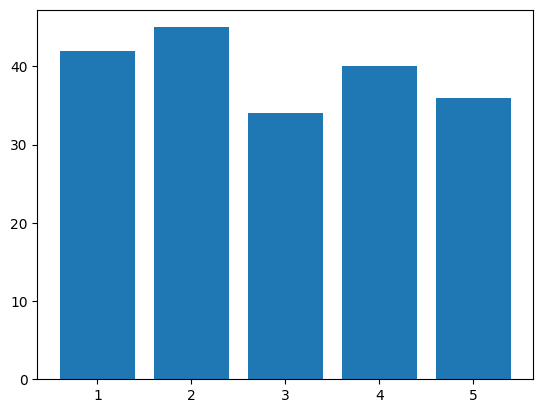

In [ ]:
lb_cnt = train.label.value_counts().sort_values()
plt.bar(lb_cnt.index, lb_cnt.values)

In [ ]:
lb_cnt

,count
label,
3,34
5,36
4,40
1,42
2,45


In [ ]:
train[train.label == 5]

,text,label
6,Как продлить страховку здоровья через онлайн-б...,5
7,“Не могу провести операцию через мобильное при...,5
11,Не могу завершить платеж через мобильное прило...,5
13,“Где я могу узнать информацию о балансе своего...,5
14,“Можно ли изменить персональные данные в мобил...,5
42,“Расскажите подробнее о рассрочке”,5
45,Не могу войти в мобильное приложение банка. Чт...,5
47,Не могу завершить транзакцию через мобильное п...,5
60,Как продлить срок действия истекающей страховк...,5
70,"Как заблокировать доступ к интернет-банку, есл...",5


In [ ]:
train['len'] = train.text.apply(lambda x: len(x.split()))

In [ ]:
import string
import nltk

In [ ]:
nltk.download('stopwords')
stop_words = nltk.corpus.stopwords.words('russian')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
word_tokenizer = nltk.WordPunctTokenizer()

In [ ]:
def process_data(data):
    texts = []
    targets = []

    for item in data.values:
        txt, label, l = item
        # print(txt)
        text_lower = txt.strip("\"\“\”.?").lower()
        tokens = word_tokenizer.tokenize(text_lower)

        # удаляем пунктуацию и стоп-слова
        # print(tokens)
        tokens = [word for word in tokens if (word not in string.punctuation and word not in stop_words)]
        # print(tokens)


        texts.append(tokens) # добавляем в предобработанный список

    return texts

In [ ]:
txt = '"Как оплатить штрафы через ваш банк?"'
tokens = word_tokenizer.tokenize(txt.strip("\"\“\”.").lower())
[word for word in tokens if (word not in string.punctuation and word not in stop_words)]
# string.punctuation

['оплатить', 'штрафы', 'ваш', 'банк']

In [ ]:
# for item in train.values:
#         txt, label, l = item
#         print(txt.strip("\"\“\”").lower())

In [ ]:
# запускаем нашу предобработку
y = train['label']
texts = process_data(train)

Теперь каждый пример представлен списком слов. Причем все слова с маленькой буквы. Пунктуацию и стоп-слова мы удалили.

In [ ]:
# example
i = 2
print("Label: ", y[i])
print("Tokens: ", texts[i])

Label:  3
Tokens:  ['избежать', 'комиссии', 'снятии', 'наличных', 'границей']


In [ ]:
!pip install pymorphy3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 61.1 MB/s eta 0:00:00


In [ ]:
# загружаем библиотеку для лемматизации
import pymorphy3 # Морфологический анализатор

# инициализируем лемматизатор :)
morph = pymorphy3.MorphAnalyzer()

In [ ]:
from tqdm.notebook import tqdm


for i in tqdm(range(len(texts))):           # tqdm_notebook создает шкалу прогресса :)
    text_lemmatized = [morph.parse(x)[0].normal_form for x in texts[i]] # применяем лемматизацию для каждого слова в тексте
    texts[i] = ' '.join(text_lemmatized)

  0%|          | 0/197 [00:00<?, ?it/s]

In [ ]:
texts

['оплатить штраф ваш банк',
 'хотеть взять автокредит какой документ необходимый',
 'избежать комиссия снятие наличный граница',
 'хотеть оформить ипотека какой условие',
 'увеличиться кредитный лимит допустить просрочка платёж',
 'изменить адрес доставка оплатить заказ сайт',
 'продлить страховка здоровье онлайн банк окончание срок действие',
 'мочь провести операция мобильный приложение',
 'узнать статус заявка кредит',
 'информация документ кредит',
 'мочь отказаться страхование кредитный карта сохранить низкий процент',
 'мочь завершить платёж мобильный приложение',
 'какой официальный документ требоваться подача заявка кредит',
 'мочь узнать информация баланс свой счёт ваш банк',
 'изменить персональный дать мобильный приложение ваш банк',
 'проверить баланс свой дебетовый карта',
 'какой акция действовать оплата карта ресторан город',
 'мочь найти раздел перевод меню интернет банк отправка деньга родственник',
 'мочь оформить кредитный карта мобильный приложение ваш банк',
 'пере

In [ ]:
from sklearn.model_selection import train_test_split
train_texts, val_texts, train_y, val_y = train_test_split(texts, y.values, test_size=0.15, random_state=42, stratify = y)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(max_features = 100)
vectorizer.fit(train_texts)

# Топ-10 слов
vectorizer.get_feature_names_out()[:10]

array(['автокредит', 'автомобиль', 'акция', 'баланс', 'банк', 'ваш',
       'взять', 'возможность', 'войти', 'дебетовый'], dtype=object)

In [ ]:
train_X = vectorizer.fit_transform(train_texts)
train_X.todense()[:2]

matrix([[0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
         0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [ ]:
val_X  = vectorizer.transform(val_texts)

In [ ]:
#import алгоритма из библиотеки
from sklearn.ensemble import RandomForestClassifier

# инициализируем модель
clf = RandomForestClassifier(n_estimators = 500, max_depth = 10)

# обучаем ее на тренировочных данных
clf = clf.fit(train_X, train_y)

# делаем предсказание для тестовых данных
pred = clf.predict(val_X)

In [ ]:
print('Предсказанные метки: ', pred[0:20], ".....")
print('Истинные метки: ', val_y[0:20], ".....")

Предсказанные метки:  [2 4 2 2 1 4 4 3 2 3 4 1 1 5 3 2 2 3 2 2] .....
Истинные метки:  [2 4 5 2 1 2 4 3 1 3 4 1 5 5 5 2 4 3 3 2] .....


In [ ]:
from sklearn.metrics import f1_score

f1_score(val_y, pred, average='macro')

0.6586441336441335

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {'n_estimators': list(range(100, 901, 100)), 'max_depth': list(range(4, 15, 2))}

grid = GridSearchCV(estimator = RandomForestClassifier(random_state=42), param_grid=params, cv=3, n_jobs=-1, verbose=1)

In [ ]:
grid.fit(train_X, train_y)

Fitting 3 folds for each of 54 candidates, totalling 162 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [4, 6, 8, 10, 12, 14],
                         'n_estimators': [100, 200, 300, 400, 500, 600, 700,
                                          800, 900]},
             verbose=1)

In [ ]:
best_rf_model = grid.best_estimator_
pred = best_rf_model.predict(val_X)

f1_score(val_y, pred, average='macro')

0.6586441336441335

In [ ]:
best_rf_model

RandomForestClassifier(max_depth=14, n_estimators=600, random_state=42)

In [ ]:
pred

array([2, 4, 2, 2, 1, 4, 4, 3, 2, 3, 4, 1, 1, 5, 3, 2, 2, 3, 2, 2, 5, 4,
       5, 1, 2, 4, 4, 3, 3, 1])

In [ ]:
grid.best_score_


0.7364718614718614

In [ ]:
#вычисляем tf-idf
from sklearn.feature_extraction.text import TfidfVectorizer
# Fit TF-IDF on train texts
vectorizer = TfidfVectorizer(max_features = 200, norm = None) # возмем топ 200 слов
vectorizer.fit(train_texts)

# Топ-10 слов
vectorizer.get_feature_names_out()[:10]

array(['10', '1000', 'sms', 'автокредит', 'автоматический', 'автомобиль',
       'адрес', 'азс', 'акция', 'баланс'], dtype=object)

In [ ]:
# Обучаем TF-IDF на train, а затем применяем к train и test
train_X = vectorizer.fit_transform(train_texts)
test_X  = vectorizer.transform(val_texts)

In [ ]:
#import алгоритма из библиотеки
from sklearn.ensemble import RandomForestClassifier

# инициализируем модель
clf = RandomForestClassifier(n_estimators = 500, max_depth = 10)

# обучаем ее на тренировочных данных
clf = clf.fit(train_X, train_y)

# делаем предсказание для тестовых данных
pred = clf.predict(test_X)

In [ ]:
from sklearn.metrics import f1_score

f1_score(val_y, pred, average='macro')

0.6210683760683761

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {'n_estimators': list(range(100, 901, 100)), 'max_depth': list(range(4, 15, 2))}

grid = GridSearchCV(estimator = RandomForestClassifier(random_state=42), param_grid=params, cv=3, n_jobs=-1, verbose=1)

In [ ]:
grid.fit(train_X, train_y)

Fitting 3 folds for each of 54 candidates, totalling 162 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [4, 6, 8, 10, 12, 14],
                         'n_estimators': [100, 200, 300, 400, 500, 600, 700,
                                          800, 900]},
             verbose=1)

In [ ]:
best_rf_model = grid.best_estimator_
pred = best_rf_model.predict(test_X)

f1_score(val_y, pred, average='macro')

0.6586441336441335

In [ ]:
best_rf_model

RandomForestClassifier(max_depth=14, n_estimators=700, random_state=42)

In [ ]:
pred

array([2, 4, 2, 2, 1, 4, 4, 3, 2, 3, 4, 1, 1, 5, 3, 2, 2, 3, 2, 2, 5, 4,
       5, 1, 2, 4, 4, 3, 3, 1])

In [ ]:
grid.best_score_


0.7003246753246753

In [ ]:
## word2vec

In [ ]:
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 10.4 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
      Successfully uninstalled scipy-1.14.1


In [ ]:
import numpy as np

In [ ]:
np.__version__

'1.26.4'

In [ ]:
texts_ = [word.split() for word in texts]
texts_

[['оплатить', 'штраф', 'ваш', 'банк'],
 ['хотеть', 'взять', 'автокредит', 'какой', 'документ', 'необходимый'],
 ['избежать', 'комиссия', 'снятие', 'наличный', 'граница'],
 ['хотеть', 'оформить', 'ипотека', 'какой', 'условие'],
 ['увеличиться', 'кредитный', 'лимит', 'допустить', 'просрочка', 'платёж'],
 ['изменить', 'адрес', 'доставка', 'оплатить', 'заказ', 'сайт'],
 ['продлить',
  'страховка',
  'здоровье',
  'онлайн',
  'банк',
  'окончание',
  'срок',
  'действие'],
 ['мочь', 'провести', 'операция', 'мобильный', 'приложение'],
 ['узнать', 'статус', 'заявка', 'кредит'],
 ['информация', 'документ', 'кредит'],
 ['мочь',
  'отказаться',
  'страхование',
  'кредитный',
  'карта',
  'сохранить',
  'низкий',
  'процент'],
 ['мочь', 'завершить', 'платёж', 'мобильный', 'приложение'],
 ['какой',
  'официальный',
  'документ',
  'требоваться',
  'подача',
  'заявка',
  'кредит'],
 ['мочь', 'узнать', 'информация', 'баланс', 'свой', 'счёт', 'ваш', 'банк'],
 ['изменить',
  'персональный',
  'дать'

In [ ]:
%%time
from gensim.models import Word2Vec
model = Word2Vec(sentences = texts_, vector_size=300, window=3, min_count=2)
# size - размерность вектора (300 - стандартная)
# window - рвзмер "окна" для контекста
# min count - минимальное кол-во раз, сколько должно встретиться слово, чтобы мы его учитывали в модели
model.save("word2v.model")

CPU times: user 30 ms, sys: 3.21 ms, total: 33.3 ms
Wall time: 76.2 ms


In [ ]:
# model.wv.index_to_key
len(model.wv.index_to_key)

143

In [ ]:
model.wv.most_similar('карта')

[('процент', 0.18494601547718048),
 ('осуществить', 0.17959271371364594),
 ('иметься', 0.16137483716011047),
 ('срок', 0.16122812032699585),
 ('перевод', 0.15526509284973145),
 ('окончание', 0.152480810880661),
 ('жизнь', 0.14077462255954742),
 ('получить', 0.13915149867534637),
 ('войти', 0.13702218234539032),
 ('задолженность', 0.12558028101921082)]

In [ ]:
top_words = []
from nltk import FreqDist
fd = FreqDist()
for text in texts_:
    fd.update(text)
for i in fd.most_common(50):
    top_words.append(i[0])
print(top_words)

['банк', 'карта', 'кредитный', 'ваш', 'мочь', 'какой', 'кредит', 'интернет', 'мой', 'узнать', 'хотеть', 'приложение', 'оформить', 'мобильный', 'получить', 'услуга', 'оплатить', 'делать', 'документ', 'баланс', 'счёт', 'другой', 'онлайн', 'свой', 'перевод', 'страховка', 'срок', 'текущий', 'продлить', 'действие', 'деньга', 'покупка', 'автомобиль', 'условие', 'проверить', 'оплата', 'комиссия', 'лимит', 'операция', 'нужный', 'оформление', 'возможность', 'взять', 'ипотека', 'платёж', 'изменить', 'сайт', 'предоставляться', 'помочь', 'коммунальный']


In [ ]:
top_words_vec = model.wv[top_words]

In [ ]:
top_words_vec.shape

(50, 300)

In [ ]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=0)
top_words_tsne = tsne.fit_transform(top_words_vec)

In [ ]:
from bokeh.models import ColumnDataSource, LabelSet
from bokeh.plotting import figure, show, output_file
from bokeh.io import output_notebook
output_notebook()

p = figure(tools="pan,wheel_zoom,reset,save",
           toolbar_location="above",
           title="word2vec T-SNE for most common words")

source = ColumnDataSource(data=dict(x1=top_words_tsne[:,0],
                                    x2=top_words_tsne[:,1],
                                    names=top_words))

p.scatter(x="x1", y="x2", size=8, source=source)

labels = LabelSet(x="x1", y="x2", text="names", y_offset=6,
                  text_font_size="8pt", text_color="#555555",
                  source=source, text_align='center')
p.add_layout(labels)

show(p)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
dist = 1 - cosine_similarity(top_words_vec)

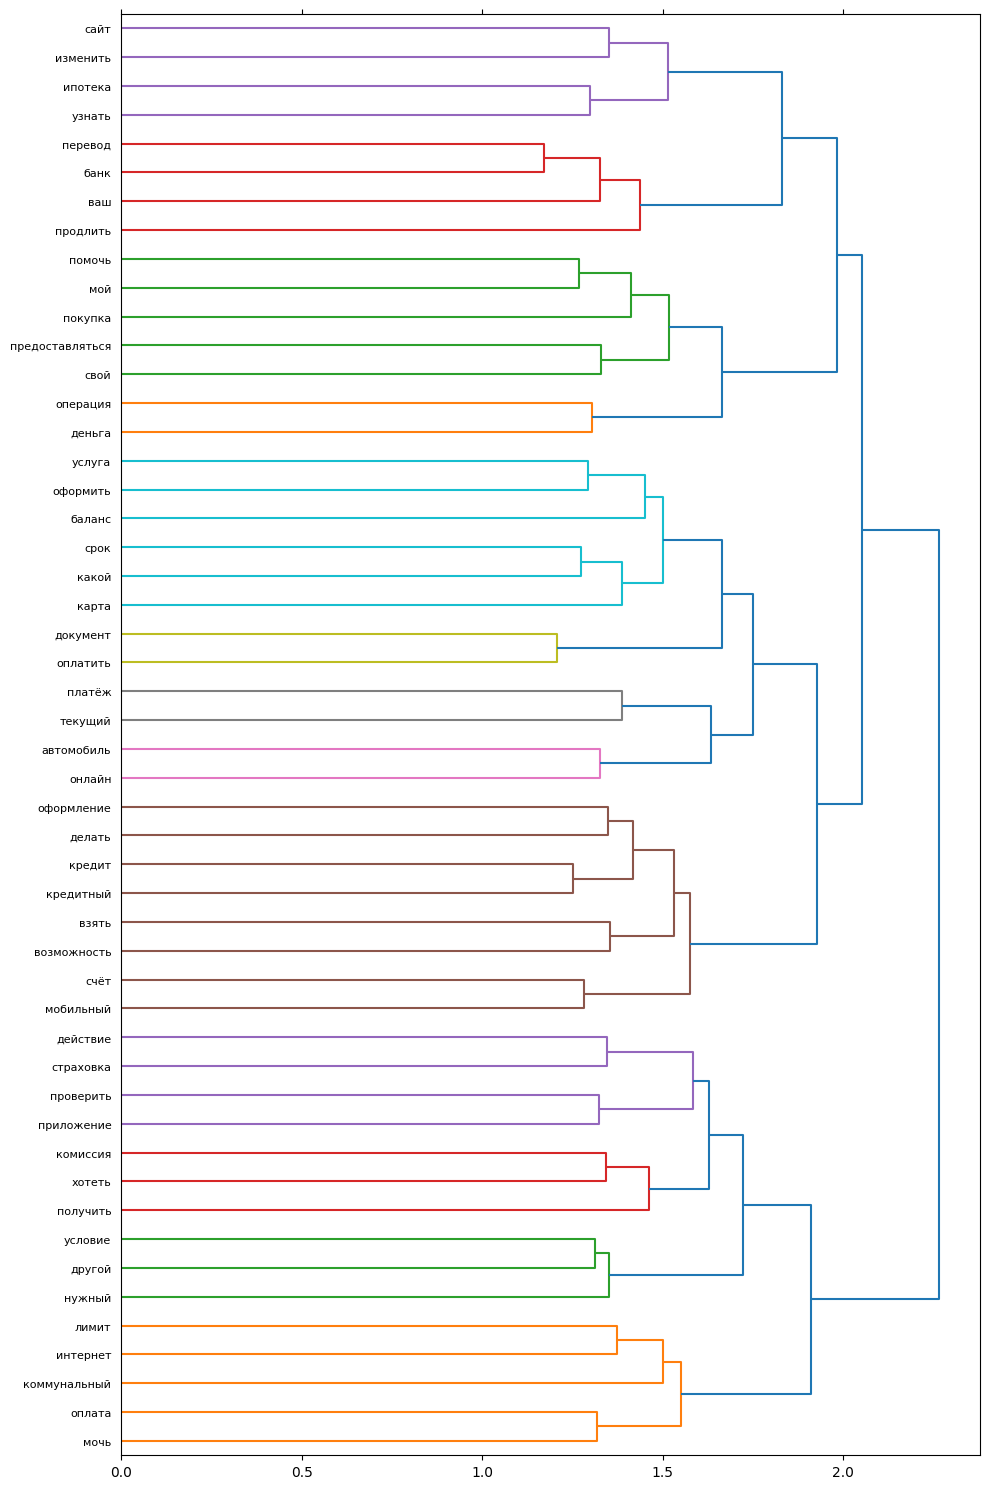

In [ ]:
from scipy.cluster.hierarchy import  ward, dendrogram

linkage_matrix = ward(dist)

fig, ax = plt.subplots(figsize=(10, 15))
ax = dendrogram(linkage_matrix, orientation="right", labels=top_words);

plt.tick_params(\
    axis= 'x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom='off',      # ticks along the bottom edge are off
    top='off',         # ticks along the top edge are off
    labelbottom='off')

plt.tight_layout()

plt.savefig('w2v_cluster.png', dpi=200) #save figure as ward_clusters

In [ ]:
y

array([5, 1, 1, 3, 3, 2, 4, 4, 3, 4, 2, 1, 4, 5, 3, 5, 2, 5, 2, 1, 1, 3,
       2, 1, 2, 5, 4, 1, 2, 2, 2, 2, 3, 3, 3, 1, 5, 2, 4, 2, 2, 1, 2, 2,
       5, 1, 1, 2, 1, 3, 1, 5, 3, 3, 1, 1, 3, 3, 4, 2, 2, 5, 4, 1, 3, 3,
       4, 1, 4, 5, 2, 4, 2, 4, 4, 1, 2, 5, 3, 4, 5, 5, 4, 3, 3, 3, 5, 2,
       4, 2, 2, 1, 4, 2, 1, 5, 4, 5, 1, 1, 4, 1, 4, 3, 3, 4, 2, 2, 2, 3,
       5, 5, 2, 1, 4, 1, 5, 1, 3, 1, 2, 3, 4, 1, 1, 3, 4, 5, 5, 2, 3, 5,
       3, 3, 4, 5, 5, 5, 1, 1, 4, 3, 3, 3, 5, 5, 5])

In [ ]:
X = texts
# y = y.values.tolist()

X, y = np.array(X), y#np.array(y)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state = 0)
print ("total train examples %s" % len(y_train))
print ("total test examples %s" % len(y_test))

ValueError: Found input variables with inconsistent numbers of samples: [197, 147]

## Mean Vector

In [ ]:
class MeanEmbeddingVectorizer(object):
    def __init__(self, word2vec):
        self.word2vec = word2vec
        # if a text is empty we should return a vector of zeros
        # with the same dimensionality as all the other vectors
        self.dim = len(w2v.popitem()[1])

    def fit(self, X, y):
        return self

    def transform(self, X):
        mean_seqs = []
        for item in X:
            seq = item.split()
            mean_seq = np.mean([self.word2vec[w] for w in seq if w in self.word2vec]
                    or [np.zeros(self.dim)], axis=0)
            # for words in X
            mean_seqs.append(mean_seq)


        return np.array(mean_seqs)



In [ ]:
w2v = dict(zip(model.wv.index_to_key, model.wv.vectors))

In [ ]:
md = MeanEmbeddingVectorizer(w2v)
md.transform(X_test)
# X_train

array([[ 4.06999607e-05, -9.78232245e-04,  3.02637898e-04, ...,
         3.43411724e-04,  3.31878517e-04,  5.22712420e-04],
       [ 1.65723905e-04, -1.17705145e-04,  8.46277515e-04, ...,
        -7.22123601e-04, -5.35194646e-04, -1.09502650e-03],
       [ 1.73331366e-03,  2.55314913e-03, -2.59830174e-03, ...,
         1.42600737e-03,  2.79517553e-04,  2.92452343e-04],
       ...,
       [ 7.25941441e-04,  9.46778673e-05,  7.54962384e-04, ...,
        -1.35675457e-03,  1.03685574e-03,  5.64165472e-04],
       [ 9.36065335e-04,  4.73412976e-04,  9.63347091e-04, ...,
        -1.01994013e-03,  5.26997959e-04, -7.29712308e-04],
       [-7.81389419e-04,  3.31342162e-05,  1.90001694e-04, ...,
        -5.75331680e-04,  8.89485993e-04, -9.45411681e-04]], dtype=float32)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rfc_w2v = Pipeline([
    ("word2vec vectorizer", MeanEmbeddingVectorizer(w2v)),
    ("extra trees", RandomForestClassifier(n_estimators=20))])


In [ ]:
rfc_w2v.fit(X_train,y_train)
pred = rfc_w2v.predict(X_test)

In [ ]:
from sklearn.metrics import  precision_score, recall_score
print("Precision: {0:6.2f}".format(precision_score(y_test, pred, average='macro')))
print("Recall: {0:6.2f}".format(recall_score(y_test, pred, average='macro')))
print("F1-measure: {0:6.2f}".format(f1_score(y_test, pred, average='macro')))
#sns.heatmap(data=confusion_matrix(y_test, pred), annot=True, fmt="d", cbar=False, xticklabels=labels, yticklabels=labels)
#plt.title("Confusion matrix")
#plt.show()

Precision:   0.66
Recall:   0.62
F1-measure:   0.61


# Средний вектор с весами tf-idf

Теперь воспользуемся более продвинутым методом получения эмбеддингов для предложений. Усредним вектора слов в предложении с весами Tf-Idf.


In [ ]:
class TfidfEmbeddingVectorizer(object):
    def __init__(self, word2vec):
        self.word2vec = word2vec
        self.word2weight = None
        self.dim = len(w2v.popitem()[1])

    # def fit(self, X, y):
    #     tfidf = TfidfVectorizer(analyzer=lambda x: x)
    #     tfidf.fit(X)
    #     max_idf = max(tfidf.idf_)
    #     self.word2weight = defaultdict(
    #         lambda: max_idf,
    #         [(w, tfidf.idf_[i]) for w, i in tfidf.vocabulary_.items()])

    #     return self

    def transform(self, X):
        tfidf = TfidfVectorizer(analyzer=lambda x: x)
        tfidf.fit(X)
        max_idf = max(tfidf.idf_)
        self.word2weight = defaultdict(
            lambda: max_idf,
            [(w, tfidf.idf_[i]) for w, i in tfidf.vocabulary_.items()])
        mean_seqs = []
        for item in X:
            seq = item.split()
            mean_seq = np.mean([self.word2vec[w]*self.word2weight[w] for w in seq if w in self.word2vec]
                    or [np.zeros(self.dim)], axis=0)
            # for words in X
            mean_seqs.append(mean_seq)


        return np.array(mean_seqs)
        # return np.array([
        #         np.mean([self.word2vec[w] * self.word2weight[w]
        #                  for w in words if w in self.word2vec] or
        #                 [np.zeros(self.dim)], axis=0)
        #         for words in X
        #     ])

In [ ]:
md = TfidfEmbeddingVectorizer(w2v)
df_train = pd.DataFrame(md.transform(X_train))
df_test = pd.DataFrame(md.transform(X_test))

In [ ]:
params = {'n_estimators': list(range(10, 400, 30)), 'max_depth': list(range(4, 11, 2))}

grid = GridSearchCV(estimator = RandomForestClassifier(random_state=42), param_grid=params, cv=3, n_jobs=-1, verbose=1)

In [ ]:
grid.fit(df_train, y_train)

Fitting 3 folds for each of 52 candidates, totalling 156 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [4, 6, 8, 10],
                         'n_estimators': [10, 40, 70, 100, 130, 160, 190, 220,
                                          250, 280, 310, 340, 370]},
             verbose=1)

In [ ]:
best_rf_model = grid.best_estimator_


pred = best_rf_model.predict(df_test)



In [ ]:
best_rf_model

RandomForestClassifier(max_depth=10, n_estimators=370, random_state=42)

In [ ]:
pred

array([4, 4, 3, 2, 1, 5, 4, 5, 2, 1, 5, 3, 1, 2, 2, 4, 2, 2, 1, 2, 1, 5,
       2, 4, 5, 5, 2, 2, 3, 1, 4, 5, 1, 5, 2, 5, 2, 2, 3, 1, 2, 4, 5, 2,
       1, 4, 2, 1, 4, 1])

In [ ]:
grid.best_score_


0.7074829931972788

In [ ]:
print("Precision: {0:6.2f}".format(precision_score(y_test, pred, average='macro')))
print("Recall: {0:6.2f}".format(recall_score(y_test, pred, average='macro')))
print("F1-measure: {0:6.2f}".format(f1_score(y_test, pred, average='macro')))

Precision:   0.69
Recall:   0.72
F1-measure:   0.69


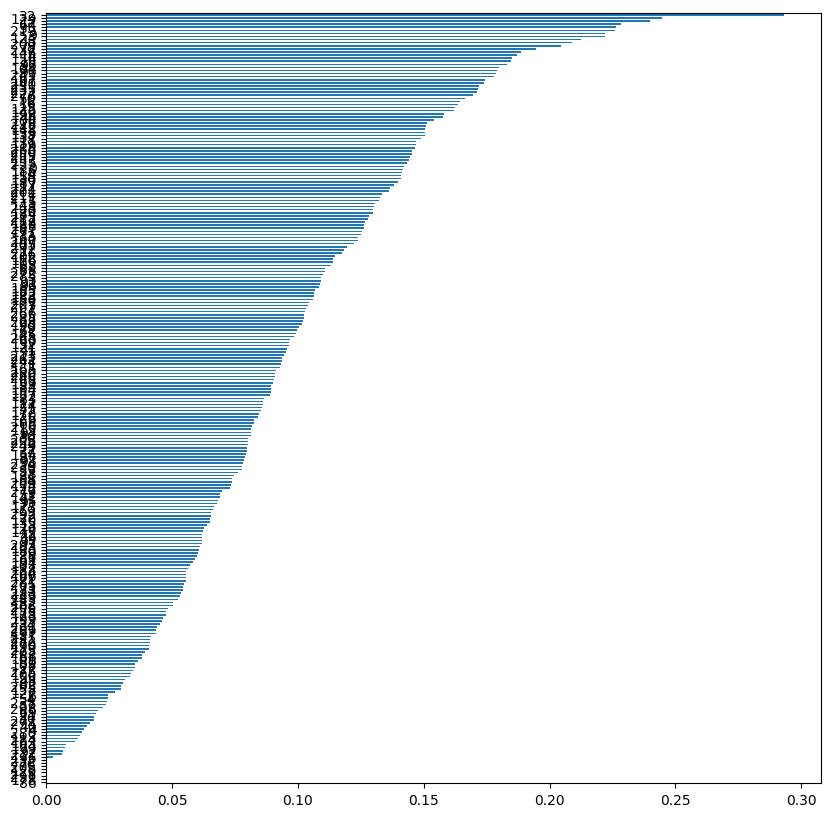

In [ ]:
from sklearn.feature_selection import mutual_info_classif

X = df_train.iloc[:, :-1]
y = y_train
importances = mutual_info_classif(X, y)
f_i = pd.Series(importances, X.columns[0:len(X.columns)])
f_i = f_i.sort_values()

plt.figure(figsize=(10, 10))
f_i.plot(kind='barh')
plt.show()


In [ ]:
new_feachures = f_i[f_i>0.01].index
new_feachures

Index([232,  54,  69, 113, 261, 291, 295,  34, 196, 239,
       ...
        14, 124,   9,  43, 200,  64,  35,  17,  32,  10],
      dtype='int64', length=250)

In [ ]:
df_train = df_train[new_feachures]
df_test = df_test[new_feachures]



In [ ]:
y

array([5, 1, 1, 3, 3, 2, 4, 4, 3, 4, 2, 1, 4, 5, 3, 5, 2, 5, 2, 1, 1, 3,
       2, 1, 2, 5, 4, 1, 2, 2, 2, 2, 3, 3, 3, 1, 5, 2, 4, 2, 2, 1, 2, 2,
       5, 1, 1, 2, 1, 3, 1, 5, 3, 3, 1, 1, 3, 3, 4, 2, 2, 5, 4, 1, 3, 3,
       4, 1, 4, 5, 2, 4, 2, 4, 4, 1, 2, 5, 3, 4, 5, 5, 4, 3, 3, 3, 5, 2,
       4, 2, 2, 1, 4, 2, 1, 5, 4, 5, 1, 1, 4, 1, 4, 3, 3, 4, 2, 2, 2, 3,
       5, 5, 2, 1, 4, 1, 5, 1, 3, 1, 2, 3, 4, 1, 1, 3, 4, 5, 5, 2, 3, 5,
       3, 3, 4, 5, 5, 5, 1, 1, 4, 3, 3, 3, 5, 5, 5])

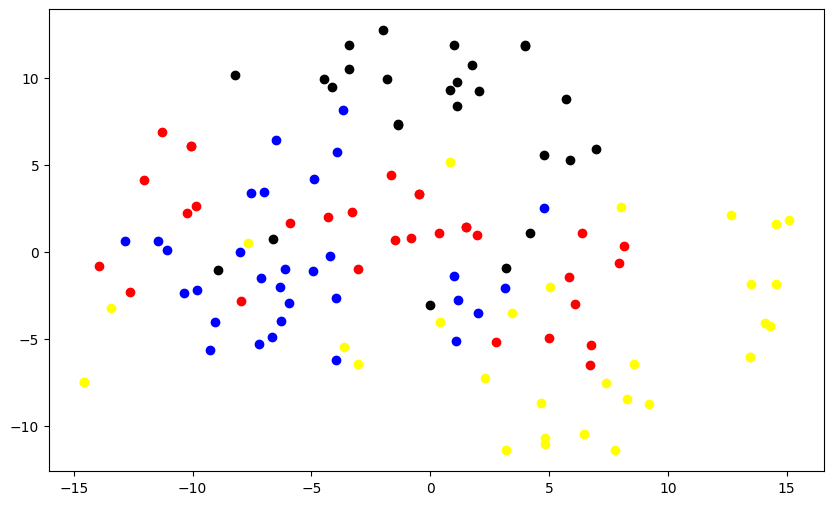

In [ ]:
from sklearn.manifold import TSNE

reduced = TSNE(n_components=2, random_state=42).fit_transform(df_train)

labels = np.array(y_train)

colors = ["green", "red", "blue", "yellow", "black"]
# labels_map = list(range(1, 6))

plt.figure(figsize=(10, 6))
for i, color in enumerate(colors):
    idx = np.where(labels == i)[0]
    plt.scatter(reduced[idx, 0], reduced[idx, 1], color=color)
plt.show()


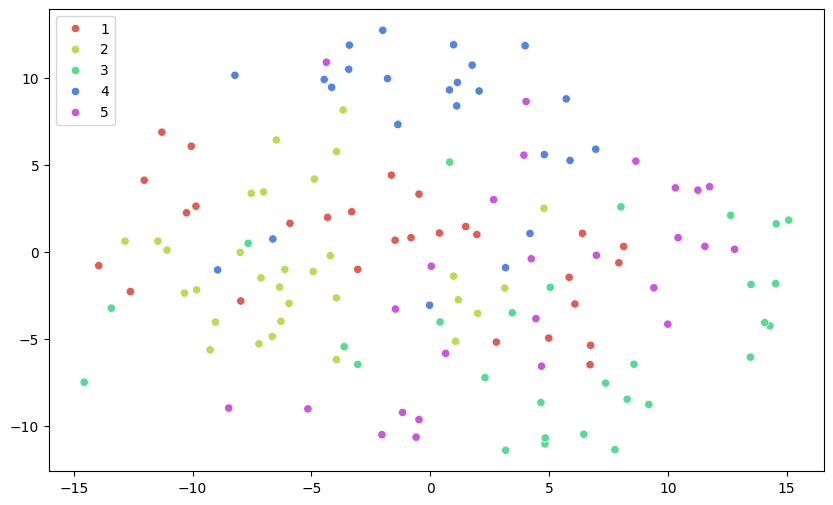

In [ ]:
from sklearn.decomposition import PCA
import seaborn as sns

# pca = PCA(n_components=100)#(hid_sts)
# pca_embedding = pca.fit_transform(df_train)



# tsne = TSNE(n_components=2, init=pca_embedding[:, :2], n_jobs=-1)
tsne_results = TSNE(n_components=2, random_state=42).fit_transform(df_train)
# tsne.fit_transform(pca_embedding)


plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=tsne_results[:,0], y=tsne_results[:,1],
    hue=y_train,
    palette=sns.color_palette("hls", 5),
    legend="full",
    alpha=1
)
plt.legend(loc='upper left')
# plt.legend(bbox_to_anchor=(1, 1), loc='upper left')